# 03.1 - Residual Ensemble Baseline Model

This notebook upgrades v2 into a calibrated baseline plus residual/direct model ensemble.

Final Revenue prediction:

```python
final_revenue = (
    0.50 * residual_lgbm_pred
    + 0.25 * residual_xgb_pred
    + 0.15 * direct_lgbm_pred
    + 0.10 * calibrated_baseline_pred
)
```

Final COGS prediction:

```python
final_cogs_direct = (
    0.60 * residual_cogs_lgbm_pred
    + 0.25 * residual_cogs_xgb_pred
    + 0.15 * calibrated_cogs_baseline_pred
)
```

`residual_*_pred` means `calibrated_baseline + predicted_residual`, clipped at zero.

## 1. Setup

In [23]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "analytical"
REPORT_DIR = PROJECT_ROOT / "reports" / "tables"
SUBMISSION_DIR = PROJECT_ROOT / "submissions"
MODEL_DIR = PROJECT_ROOT / "models"

SALES_PATH = DATA_DIR / "sales.csv"
SAMPLE_SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"
VALIDATION_RESULTS_PATH = REPORT_DIR / "03_1_residual_ensemble_validation_results.csv"
BASELINE_WEIGHTS_PATH = REPORT_DIR / "03_1_residual_ensemble_baseline_weights.csv"
CALIBRATION_PATH = REPORT_DIR / "03_1_residual_ensemble_calibration.csv"
FEATURE_IMPORTANCE_PATH = REPORT_DIR / "03_1_residual_ensemble_feature_importance.csv"
SUBMISSION_PATH = SUBMISSION_DIR / "submission_03_1_residual_ensemble.csv"
CONFIG_PATH = MODEL_DIR / "03_1_residual_ensemble_config.json"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COLS = ["Revenue", "COGS"]
BASELINE_FEATURES = ["lag_364", "lag_365", "lag_371", "rolling_7", "rolling_30", "rolling_90"]
FOURIER_PERIODS = [7, 30.5, 365.25]
FOURIER_K = [1, 2, 3]

REVENUE_ENSEMBLE_WEIGHTS = {
    "residual_lgbm": 0.50,
    "residual_xgb": 0.25,
    "direct_lgbm": 0.15,
    "calibrated_baseline": 0.10,
}
COGS_ENSEMBLE_WEIGHTS = {
    "residual_lgbm": 0.60,
    "residual_xgb": 0.25,
    "calibrated_baseline": 0.15,
}

VALIDATION_START = pd.Timestamp("2022-01-01")
VALIDATION_END = pd.Timestamp("2022-12-31")
FORECAST_START = pd.Timestamp("2023-01-01")
FORECAST_END = pd.Timestamp("2024-07-01")
INNER_WEIGHT_VALIDATION_START = pd.Timestamp("2021-01-01")

## 2. Load Processed Daily Sales

The analytical `sales.csv` is already processed. This section only parses dates and sorts rows chronologically.

In [24]:
sales = pd.read_csv(SALES_PATH, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH, parse_dates=["Date"])

assert sales["Date"].is_monotonic_increasing
assert sales[TARGET_COLS].notna().all().all()
assert not sales["Date"].duplicated().any()

DATA_START = sales["Date"].min()

print("Sales shape:", sales.shape)
print("Sales range:", sales["Date"].min().date(), "to", sales["Date"].max().date())
print("Sample submission range:", sample_submission["Date"].min().date(), "to", sample_submission["Date"].max().date())
sales.head()

Sales shape: (3833, 3)
Sales range: 2012-07-04 to 2022-12-31
Sample submission range: 2023-01-01 to 2024-07-01


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


## 3. Feature Builders

In [25]:
def add_calendar_event_features(df: pd.DataFrame, data_start: pd.Timestamp = DATA_START) -> pd.DataFrame:
    out = df.copy()
    dt = out["Date"].dt
    iso = dt.isocalendar()

    out["month"] = dt.month.astype(int)
    out["dayofweek"] = dt.dayofweek.astype(int)
    out["dayofmonth"] = dt.day.astype(int)
    out["weekofyear"] = iso.week.astype(int)
    out["is_weekend"] = out["dayofweek"].isin([5, 6]).astype(int)
    out["is_month_start"] = dt.is_month_start.astype(int)
    out["is_month_end"] = dt.is_month_end.astype(int)
    out["is_quarter_start"] = dt.is_quarter_start.astype(int)
    out["is_quarter_end"] = dt.is_quarter_end.astype(int)
    out["days_from_start"] = (out["Date"] - data_start).dt.days.astype(int)

    day_index = out["days_from_start"].to_numpy()
    for period in FOURIER_PERIODS:
        label = str(period).replace(".", "_")
        for k in FOURIER_K:
            out[f"sin_{label}_{k}"] = np.sin(2 * np.pi * k * day_index / period)
            out[f"cos_{label}_{k}"] = np.cos(2 * np.pi * k * day_index / period)

    m = out["month"]
    d = out["dayofmonth"]
    doy = dt.dayofyear

    out["event_new_year"] = (((m == 12) & (d >= 29)) | ((m == 1) & (d <= 5))).astype(int)
    out["event_tet_like"] = (((m == 1) & (d >= 20)) | ((m == 2) & (d <= 10))).astype(int)
    out["event_valentine"] = ((m == 2) & d.between(10, 15)).astype(int)
    out["event_womens_day"] = ((m == 3) & d.between(5, 9)).astype(int)
    out["event_mid_year_sale"] = (((m == 6) & (d >= 15)) | ((m == 7) & (d <= 7))).astype(int)
    out["event_back_to_school"] = ((m == 8) | ((m == 9) & (d <= 10))).astype(int)
    out["event_9_9"] = ((m == 9) & d.between(7, 11)).astype(int)
    out["event_10_10"] = ((m == 10) & d.between(8, 12)).astype(int)
    out["event_11_11"] = ((m == 11) & d.between(9, 13)).astype(int)
    out["event_12_12"] = ((m == 12) & d.between(10, 14)).astype(int)
    out["event_christmas_year_end"] = ((m == 12) & (d >= 20)).astype(int)
    out["event_payday"] = ((d >= 25) | (d <= 5)).astype(int)

    event_centers = {
        "new_year": 1,
        "tet_like": 32,
        "valentine": 45,
        "womens_day": 67,
        "mid_year_sale": 181,
        "back_to_school": 244,
        "9_9": 252,
        "10_10": 283,
        "11_11": 315,
        "12_12": 346,
        "christmas_year_end": 359,
    }
    for name, center in event_centers.items():
        circular_distance = np.minimum(np.abs(doy - center), 366 - np.abs(doy - center))
        out[f"days_to_{name}"] = circular_distance.astype(int)

    return out


def build_actual_feature_table(df: pd.DataFrame) -> pd.DataFrame:
    out = add_calendar_event_features(df[["Date", *TARGET_COLS]].copy())
    for target in TARGET_COLS:
        s = df[target]
        out[f"{target}_lag_364"] = s.shift(364)
        out[f"{target}_lag_365"] = s.shift(365)
        out[f"{target}_lag_371"] = s.shift(371)
        out[f"{target}_rolling_7"] = s.shift(1).rolling(7).mean()
        out[f"{target}_rolling_30"] = s.shift(1).rolling(30).mean()
        out[f"{target}_rolling_90"] = s.shift(1).rolling(90).mean()
        out[f"{target}_yoy_lag_364_growth"] = s.shift(364) / s.shift(728).replace(0, np.nan) - 1
        out[f"{target}_yoy_lag_365_growth"] = s.shift(365) / s.shift(730).replace(0, np.nan) - 1
        out[f"{target}_rolling_30_yoy_growth"] = s.shift(1).rolling(30).mean() / s.shift(365).rolling(30).mean().replace(0, np.nan) - 1
    return out


def baseline_feature_array_from_values(values: list[float]) -> np.ndarray:
    return np.array([
        values[-364],
        values[-365],
        values[-371],
        np.mean(values[-7:]),
        np.mean(values[-30:]),
        np.mean(values[-90:]),
    ], dtype=float)


def yoy_growth_from_values(values: list[float]) -> dict[str, float]:
    lag_728 = values[-728] if len(values) >= 728 else np.nan
    lag_730 = values[-730] if len(values) >= 730 else np.nan
    rolling_30 = np.mean(values[-30:]) if len(values) >= 30 else np.nan
    rolling_30_last_year = np.mean(values[-395:-365]) if len(values) >= 395 else np.nan
    return {
        "yoy_lag_364_growth": values[-364] / lag_728 - 1 if lag_728 and np.isfinite(lag_728) else 0.0,
        "yoy_lag_365_growth": values[-365] / lag_730 - 1 if lag_730 and np.isfinite(lag_730) else 0.0,
        "rolling_30_yoy_growth": rolling_30 / rolling_30_last_year - 1 if rolling_30_last_year and np.isfinite(rolling_30_last_year) else 0.0,
    }

## 4. Optimized Baseline and Calibration

In [26]:
def optimize_baseline_weights(feature_table: pd.DataFrame, target: str, fit_end: pd.Timestamp) -> np.ndarray:
    cols = [f"{target}_{feature}" for feature in BASELINE_FEATURES]
    train = feature_table[(feature_table["Date"] < fit_end) & feature_table[cols + [target]].notna().all(axis=1)]
    inner_val = train[train["Date"] >= INNER_WEIGHT_VALIDATION_START]
    if len(inner_val) < 90:
        inner_val = train.tail(365)

    X = inner_val[cols].to_numpy(dtype=float)
    y = inner_val[target].to_numpy(dtype=float)

    def objective(weights: np.ndarray) -> float:
        return math.sqrt(mean_squared_error(y, X @ weights))

    starts = [
        np.array([1, 0, 0, 0, 0, 0], dtype=float),
        np.array([0, 1, 0, 0, 0, 0], dtype=float),
        np.array([0, 0, 1, 0, 0, 0], dtype=float),
        np.array([0.45, 0.35, 0.05, 0.10, 0.03, 0.02], dtype=float),
        np.repeat(1 / len(BASELINE_FEATURES), len(BASELINE_FEATURES)),
    ]
    bounds = [(0.0, 1.0)] * len(BASELINE_FEATURES)
    constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1.0}

    best = None
    for start in starts:
        result = minimize(
            objective,
            start / start.sum(),
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={"maxiter": 300, "ftol": 1e-8},
        )
        if best is None or result.fun < best.fun:
            best = result

    weights = np.maximum(best.x, 0)
    return weights / weights.sum()


def apply_baseline_predictions(feature_table: pd.DataFrame, weights_by_target: dict[str, np.ndarray]) -> pd.DataFrame:
    out = feature_table.copy()
    for target in TARGET_COLS:
        cols = [f"{target}_{feature}" for feature in BASELINE_FEATURES]
        out[f"{target}_baseline_raw"] = out[cols].to_numpy(dtype=float) @ weights_by_target[target]
    return out


def shrink_factor(raw_factor: float, n: int, strength: int, lower: float, upper: float) -> float:
    if not np.isfinite(raw_factor):
        raw_factor = 1.0
    shrunk = 1.0 + (raw_factor - 1.0) * (n / (n + strength))
    return float(np.clip(shrunk, lower, upper))


def build_calibration(table: pd.DataFrame, fit_mask: pd.Series, pred_suffix: str = "baseline_raw") -> tuple[dict, pd.DataFrame]:
    fit = table.loc[fit_mask].copy()
    calibration = {}
    rows = []
    for target in TARGET_COLS:
        pred_col = f"{target}_{pred_suffix}"
        ratio_col = f"{target}_ratio"
        fit[ratio_col] = fit[target] / fit[pred_col].replace(0, np.nan)
        fit[ratio_col] = fit[ratio_col].replace([np.inf, -np.inf], np.nan).fillna(1.0)

        month_factors = {}
        for month, group in fit.groupby("month"):
            factor = shrink_factor(group[ratio_col].median(), len(group), strength=60, lower=0.80, upper=1.20)
            month_factors[int(month)] = factor
            rows.append({"target": target, "level": "month", "month": int(month), "dayofweek": None, "factor": factor, "n": len(group)})

        fit[f"{target}_month_adjusted_ratio"] = fit[ratio_col] / fit["month"].map(month_factors)
        weekday_month_factors = {}
        for (month, dayofweek), group in fit.groupby(["month", "dayofweek"]):
            factor = shrink_factor(group[f"{target}_month_adjusted_ratio"].median(), len(group), strength=20, lower=0.90, upper=1.10)
            weekday_month_factors[(int(month), int(dayofweek))] = factor
            rows.append({"target": target, "level": "weekday_month", "month": int(month), "dayofweek": int(dayofweek), "factor": factor, "n": len(group)})

        calibration[target] = {"month_factors": month_factors, "weekday_month_factors": weekday_month_factors}

    return calibration, pd.DataFrame(rows)


def get_calibration_factor(date: pd.Timestamp, target: str, calibration: dict) -> float:
    month = int(date.month)
    dayofweek = int(date.dayofweek)
    target_cal = calibration[target]
    return float(target_cal["month_factors"].get(month, 1.0) * target_cal["weekday_month_factors"].get((month, dayofweek), 1.0))


def apply_calibration(table: pd.DataFrame, calibration: dict) -> pd.DataFrame:
    out = table.copy()
    for target in TARGET_COLS:
        factors = out["Date"].map(lambda d: get_calibration_factor(d, target, calibration))
        out[f"{target}_baseline_calibrated"] = out[f"{target}_baseline_raw"] * factors
    return out

feature_table = build_actual_feature_table(sales)
weights_validation = {target: optimize_baseline_weights(feature_table, target, VALIDATION_START) for target in TARGET_COLS}
feature_table = apply_baseline_predictions(feature_table, weights_validation)
calibration_validation, calibration_validation_table = build_calibration(
    feature_table,
    (feature_table["Date"] < VALIDATION_START) & feature_table[[f"{t}_baseline_raw" for t in TARGET_COLS]].notna().all(axis=1),
)
feature_table = apply_calibration(feature_table, calibration_validation)

weights_validation_table = pd.DataFrame([
    {"target": target, "feature": feature, "weight": float(weight)}
    for target in TARGET_COLS
    for feature, weight in zip(BASELINE_FEATURES, weights_validation[target])
])
weights_validation_table

,target,feature,weight
0,Revenue,lag_364,0.345389
1,Revenue,lag_365,0.272717
2,Revenue,lag_371,0.038377
3,Revenue,rolling_7,0.282151
4,Revenue,rolling_30,0.046016
5,Revenue,rolling_90,0.015351
6,COGS,lag_364,0.208789
7,COGS,lag_365,0.601394
8,COGS,lag_371,0.031365
9,COGS,rolling_7,0.092323


## 5. Residual and Direct Model Training Tables

In [27]:
BASE_MODEL_FEATURES = [
    "baseline_prediction",
    "month",
    "dayofweek",
    "dayofmonth",
    "weekofyear",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "is_quarter_start",
    "is_quarter_end",
    "days_from_start",
]
FOURIER_FEATURES = [
    f"{trig}_{str(period).replace('.', '_')}_{k}"
    for period in FOURIER_PERIODS
    for k in FOURIER_K
    for trig in ["sin", "cos"]
]
EVENT_FEATURES = [
    "event_new_year",
    "event_tet_like",
    "event_valentine",
    "event_womens_day",
    "event_mid_year_sale",
    "event_back_to_school",
    "event_9_9",
    "event_10_10",
    "event_11_11",
    "event_12_12",
    "event_christmas_year_end",
    "event_payday",
    "days_to_new_year",
    "days_to_tet_like",
    "days_to_valentine",
    "days_to_womens_day",
    "days_to_mid_year_sale",
    "days_to_back_to_school",
    "days_to_9_9",
    "days_to_10_10",
    "days_to_11_11",
    "days_to_12_12",
    "days_to_christmas_year_end",
]
YOY_FEATURES = ["yoy_lag_364_growth", "yoy_lag_365_growth", "rolling_30_yoy_growth"]
MODEL_FEATURES = BASE_MODEL_FEATURES + FOURIER_FEATURES + EVENT_FEATURES + YOY_FEATURES


def model_table_for_target(table: pd.DataFrame, target: str) -> pd.DataFrame:
    out = table[["Date", target, f"{target}_baseline_calibrated"]].copy()
    out = out.rename(columns={f"{target}_baseline_calibrated": "baseline_prediction"})
    shared_cols = [c for c in MODEL_FEATURES if c not in ["baseline_prediction", *YOY_FEATURES]]
    out[shared_cols] = table[shared_cols]
    for feature in YOY_FEATURES:
        out[feature] = table[f"{target}_{feature}"]
    out["residual"] = out[target] - out["baseline_prediction"]
    return out.dropna(subset=MODEL_FEATURES + [target, "residual"])

model_tables = {target: model_table_for_target(feature_table, target) for target in TARGET_COLS}
for target, table in model_tables.items():
    print(target, table.shape, table["Date"].min().date(), table["Date"].max().date())

Revenue (3103, 58) 2014-07-04 2022-12-31
COGS (3103, 58) 2014-07-04 2022-12-31


## 6. Train Residual and Direct Models

In [28]:
def make_lgbm_regressor():
    from lightgbm import LGBMRegressor
    return LGBMRegressor(
        objective="regression",
        n_estimators=350,
        learning_rate=0.035,
        num_leaves=31,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=-1,
    )


def make_xgb_regressor():
    from xgboost import XGBRegressor
    return XGBRegressor(
        objective="reg:squarederror",
        n_estimators=350,
        learning_rate=0.035,
        max_depth=4,
        min_child_weight=3,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        tree_method="hist",
    )


def train_target_models(model_tables: dict[str, pd.DataFrame], train_end: pd.Timestamp) -> dict:
    trained = {
        "residual_lgbm": {},
        "residual_xgb": {},
        "direct_lgbm": {},
    }
    for target in TARGET_COLS:
        train = model_tables[target][model_tables[target]["Date"] < train_end]
        X_train = train[MODEL_FEATURES]

        residual_lgbm = make_lgbm_regressor()
        residual_lgbm.fit(X_train, train["residual"])
        trained["residual_lgbm"][target] = residual_lgbm

        residual_xgb = make_xgb_regressor()
        residual_xgb.fit(X_train, train["residual"])
        trained["residual_xgb"][target] = residual_xgb

        if target == "Revenue":
            direct_lgbm = make_lgbm_regressor()
            direct_lgbm.fit(X_train, train[target])
            trained["direct_lgbm"][target] = direct_lgbm

    return trained

validation_models = train_target_models(model_tables, VALIDATION_START)
print("Trained validation models: residual LGBM/XGB for Revenue and COGS, direct LGBM for Revenue")

Trained validation models: residual LGBM/XGB for Revenue and COGS, direct LGBM for Revenue


## 7. Recursive Prediction Helpers

In [29]:
def model_feature_row_for_date(date: pd.Timestamp, target: str, baseline_prediction: float, values: list[float]) -> pd.DataFrame:
    row = pd.DataFrame({"Date": [date]})
    row = add_calendar_event_features(row)
    row["baseline_prediction"] = baseline_prediction
    growth = yoy_growth_from_values(values)
    for feature, value in growth.items():
        row[feature] = value
    return row[MODEL_FEATURES]


def combine_revenue_predictions(
    calibrated_baseline_pred: float,
    residual_lgbm_pred: float,
    residual_xgb_pred: float,
    direct_lgbm_pred: float,
) -> float:
    return max(
        REVENUE_ENSEMBLE_WEIGHTS["residual_lgbm"] * residual_lgbm_pred
        + REVENUE_ENSEMBLE_WEIGHTS["residual_xgb"] * residual_xgb_pred
        + REVENUE_ENSEMBLE_WEIGHTS["direct_lgbm"] * direct_lgbm_pred
        + REVENUE_ENSEMBLE_WEIGHTS["calibrated_baseline"] * calibrated_baseline_pred,
        0.0,
    )


def combine_cogs_predictions(
    calibrated_cogs_baseline_pred: float,
    residual_cogs_lgbm_pred: float,
    residual_cogs_xgb_pred: float,
) -> float:
    return max(
        COGS_ENSEMBLE_WEIGHTS["residual_lgbm"] * residual_cogs_lgbm_pred
        + COGS_ENSEMBLE_WEIGHTS["residual_xgb"] * residual_cogs_xgb_pred
        + COGS_ENSEMBLE_WEIGHTS["calibrated_baseline"] * calibrated_cogs_baseline_pred,
        0.0,
    )


def recursive_ensemble_forecast(
    history: pd.DataFrame,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    weights_by_target: dict[str, np.ndarray],
    calibration: dict,
    trained_models: dict | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    expected_next_date = history["Date"].max() + pd.Timedelta(days=1)
    assert expected_next_date == start_date, f"History must end on {start_date - pd.Timedelta(days=1):%Y-%m-%d}"

    target_values = {target: history[target].astype(float).tolist() for target in TARGET_COLS}
    rows = []
    component_rows = []

    for forecast_date in pd.date_range(start_date, end_date, freq="D"):
        component = {"Date": forecast_date}
        baseline = {}
        residual_lgbm_final = {}
        residual_xgb_final = {}

        for target in TARGET_COLS:
            baseline_raw = float(np.dot(weights_by_target[target], baseline_feature_array_from_values(target_values[target])))
            baseline[target] = max(baseline_raw * get_calibration_factor(forecast_date, target, calibration), 0.0)
            component[f"{target}_calibrated_baseline"] = baseline[target]

            if trained_models is None:
                residual_lgbm_final[target] = baseline[target]
                residual_xgb_final[target] = baseline[target]
            else:
                X_next = model_feature_row_for_date(forecast_date, target, baseline[target], target_values[target])
                residual_lgbm = float(trained_models["residual_lgbm"][target].predict(X_next)[0])
                residual_xgb = float(trained_models["residual_xgb"][target].predict(X_next)[0])
                residual_lgbm_final[target] = max(baseline[target] + residual_lgbm, 0.0)
                residual_xgb_final[target] = max(baseline[target] + residual_xgb, 0.0)
                component[f"{target}_residual_lgbm"] = residual_lgbm
                component[f"{target}_residual_xgb"] = residual_xgb
                component[f"{target}_residual_lgbm_pred"] = residual_lgbm_final[target]
                component[f"{target}_residual_xgb_pred"] = residual_xgb_final[target]

        if trained_models is None:
            final_revenue = baseline["Revenue"]
            final_cogs = baseline["COGS"]
        else:
            X_rev = model_feature_row_for_date(forecast_date, "Revenue", baseline["Revenue"], target_values["Revenue"])
            direct_lgbm_pred = max(float(trained_models["direct_lgbm"]["Revenue"].predict(X_rev)[0]), 0.0)
            component["Revenue_direct_lgbm_pred"] = direct_lgbm_pred

            final_revenue = combine_revenue_predictions(
                calibrated_baseline_pred=baseline["Revenue"],
                residual_lgbm_pred=residual_lgbm_final["Revenue"],
                residual_xgb_pred=residual_xgb_final["Revenue"],
                direct_lgbm_pred=direct_lgbm_pred,
            )
            final_cogs = combine_cogs_predictions(
                calibrated_cogs_baseline_pred=baseline["COGS"],
                residual_cogs_lgbm_pred=residual_lgbm_final["COGS"],
                residual_cogs_xgb_pred=residual_xgb_final["COGS"],
            )

        row = {"Date": forecast_date, "Revenue": final_revenue, "COGS": final_cogs}
        rows.append(row)
        component["Revenue_final"] = final_revenue
        component["COGS_final"] = final_cogs
        component_rows.append(component)

        target_values["Revenue"].append(final_revenue)
        target_values["COGS"].append(final_cogs)

    return pd.DataFrame(rows), pd.DataFrame(component_rows)

## 8. Validation

In [30]:
def regression_metrics(actual: pd.DataFrame, predicted: pd.DataFrame, model_name: str) -> pd.DataFrame:
    rows = []
    for target in TARGET_COLS:
        rmse = math.sqrt(mean_squared_error(actual[target], predicted[target]))
        rows.append({
            "model": model_name,
            "target": target,
            "MAE": mean_absolute_error(actual[target], predicted[target]),
            "RMSE": rmse,
            "R2": r2_score(actual[target], predicted[target]),
        })
    rows.append({
        "model": model_name,
        "target": "average",
        "MAE": float(np.mean([row["MAE"] for row in rows])),
        "RMSE": float(np.mean([row["RMSE"] for row in rows])),
        "R2": float(np.mean([row["R2"] for row in rows])),
    })
    return pd.DataFrame(rows)

validation_history = sales[sales["Date"] < VALIDATION_START].copy()
validation_actual = sales[(sales["Date"] >= VALIDATION_START) & (sales["Date"] <= VALIDATION_END)].copy()

validation_baseline_pred, validation_baseline_components = recursive_ensemble_forecast(
    validation_history,
    VALIDATION_START,
    VALIDATION_END,
    weights_validation,
    calibration_validation,
    trained_models=None,
)
validation_ensemble_pred, validation_ensemble_components = recursive_ensemble_forecast(
    validation_history,
    VALIDATION_START,
    VALIDATION_END,
    weights_validation,
    calibration_validation,
    trained_models=validation_models,
)

validation_table = pd.concat(
    [
        regression_metrics(validation_actual, validation_baseline_pred, "calibrated_baseline"),
        regression_metrics(validation_actual, validation_ensemble_pred, "fixed_residual_ensemble"),
    ],
    ignore_index=True,
)
validation_table.sort_values(["target", "RMSE"]).reset_index(drop=True)

,model,target,MAE,RMSE,R2
0,fixed_residual_ensemble,COGS,582299.819741,7.645354e+05,0.725247
1,calibrated_baseline,COGS,654447.275828,8.667926e+05,0.646835
2,fixed_residual_ensemble,Revenue,622494.694708,8.313530e+05,0.753306
3,calibrated_baseline,Revenue,865144.739488,1.176430e+06,0.506008
4,fixed_residual_ensemble,average,602397.257224,7.979442e+05,0.739277
5,calibrated_baseline,average,759796.007658,1.021612e+06,0.576421


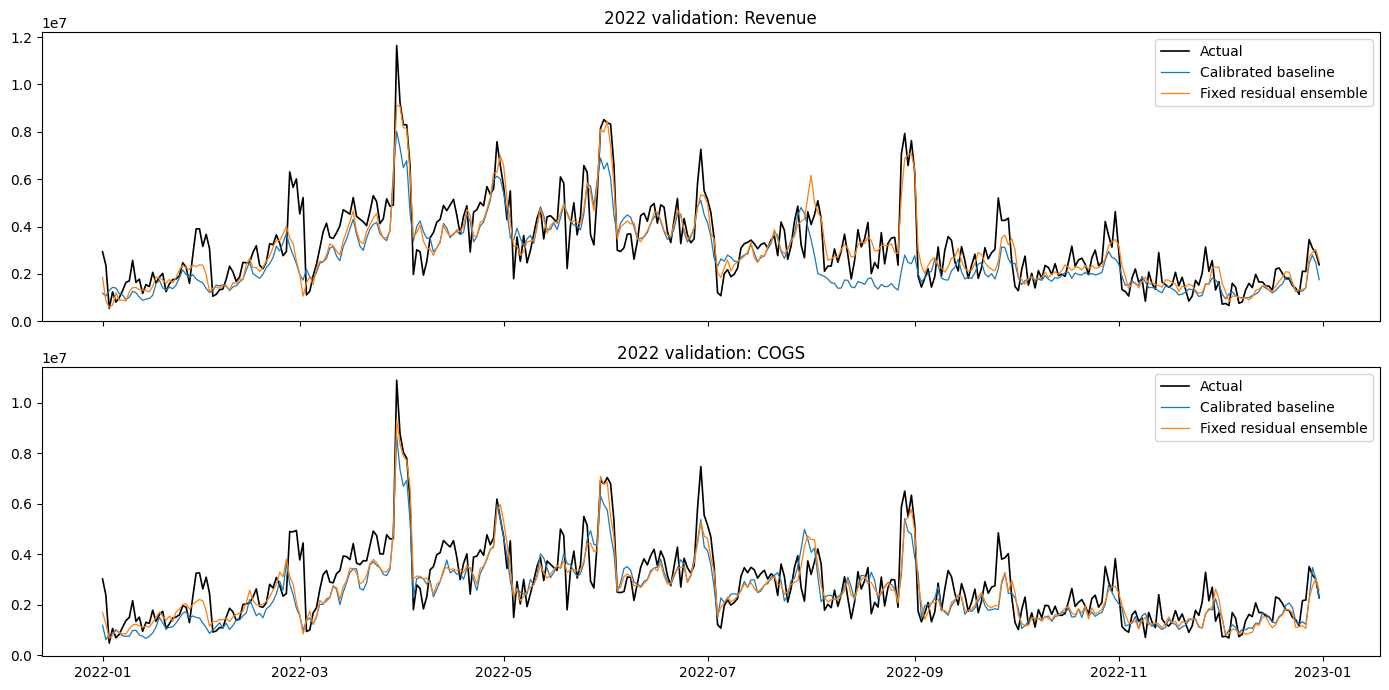

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, target in zip(axes, TARGET_COLS):
    ax.plot(validation_actual["Date"], validation_actual[target], label="Actual", linewidth=1.2, color="black")
    ax.plot(validation_baseline_pred["Date"], validation_baseline_pred[target], label="Calibrated baseline", linewidth=0.9)
    ax.plot(validation_ensemble_pred["Date"], validation_ensemble_pred[target], label="Fixed residual ensemble", linewidth=0.9)
    ax.set_title(f"2022 validation: {target}")
    ax.legend()
plt.tight_layout()
plt.show()

## 9. Final Fit and Forecast

In [32]:
final_feature_table = build_actual_feature_table(sales)
weights_final = {target: optimize_baseline_weights(final_feature_table, target, FORECAST_START) for target in TARGET_COLS}
final_feature_table = apply_baseline_predictions(final_feature_table, weights_final)
calibration_final, calibration_final_table = build_calibration(
    final_feature_table,
    final_feature_table[[f"{t}_baseline_raw" for t in TARGET_COLS]].notna().all(axis=1),
)
final_feature_table = apply_calibration(final_feature_table, calibration_final)
final_model_tables = {target: model_table_for_target(final_feature_table, target) for target in TARGET_COLS}
final_models = train_target_models(final_model_tables, FORECAST_START)

forecast, forecast_components = recursive_ensemble_forecast(
    sales,
    FORECAST_START,
    FORECAST_END,
    weights_final,
    calibration_final,
    trained_models=final_models,
)

submission = sample_submission[["Date"]].merge(forecast, on="Date", how="left")
assert submission[TARGET_COLS].notna().all().all()
assert submission["Date"].tolist() == sample_submission["Date"].tolist()
assert (submission[TARGET_COLS] >= 0).all().all()

submission_to_save = submission.copy()
submission_to_save["Date"] = submission_to_save["Date"].dt.strftime("%Y-%m-%d")
submission_to_save[TARGET_COLS] = submission_to_save[TARGET_COLS].round(2)
submission_to_save.to_csv(SUBMISSION_PATH, index=False)

print("Saved submission:", SUBMISSION_PATH)
submission_to_save.head()

Saved submission: D:\Project\DATATHON-2026-r1\submissions\submission_03_1_residual_ensemble.csv


,Date,Revenue,COGS
0,2023-01-01,2510271.66,2834617.78
1,2023-01-02,1801037.55,1604033.40
2,2023-01-03,1105783.67,1134477.67
3,2023-01-04,957576.37,745822.06
4,2023-01-05,991053.15,1007410.56


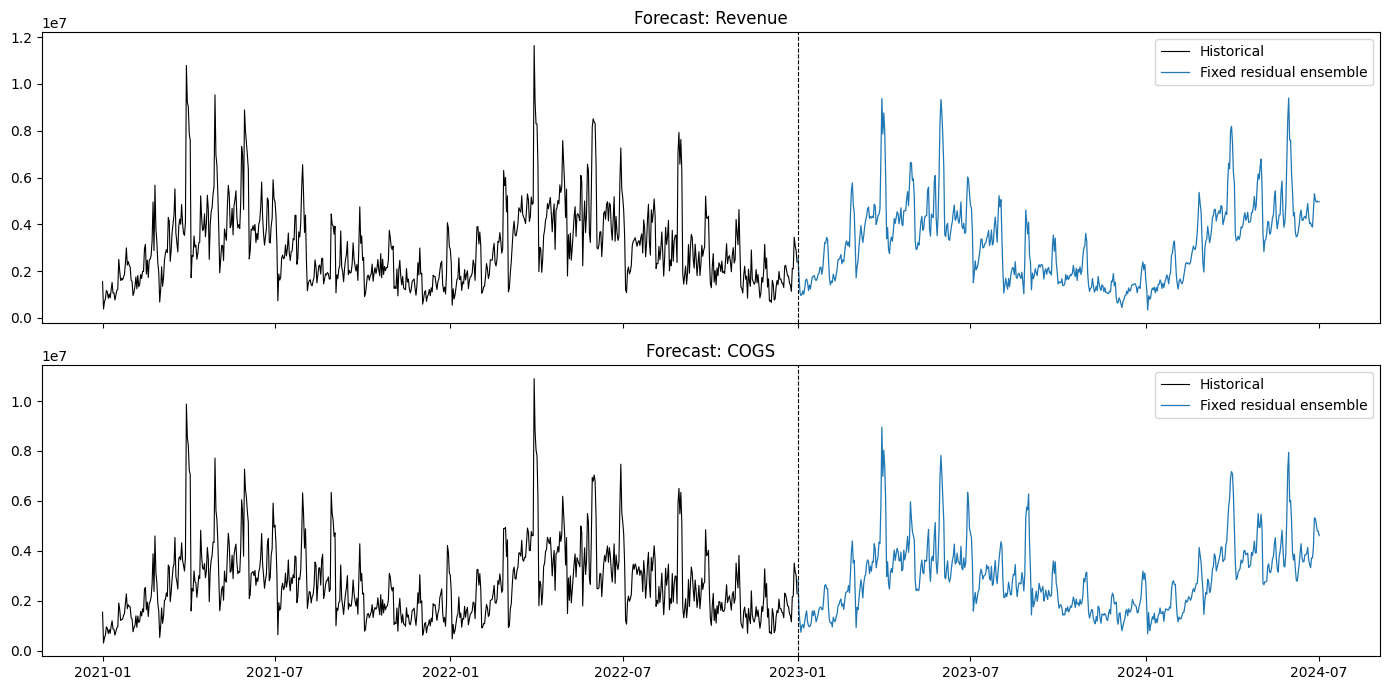

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
recent_history = sales[sales["Date"] >= "2021-01-01"]
for ax, target in zip(axes, TARGET_COLS):
    ax.plot(recent_history["Date"], recent_history[target], label="Historical", linewidth=0.8, color="black")
    ax.plot(forecast["Date"], forecast[target], label="Fixed residual ensemble", linewidth=0.9)
    ax.axvline(FORECAST_START, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(f"Forecast: {target}")
    ax.legend()
plt.tight_layout()
plt.show()

## 10. Explainability and Save Results

In [34]:
def collect_feature_importance(models: dict) -> pd.DataFrame:
    rows = []
    for model_group, target_models in models.items():
        for target, model in target_models.items():
            importances = getattr(model, "feature_importances_", np.zeros(len(MODEL_FEATURES)))
            for feature, importance in zip(MODEL_FEATURES, importances):
                rows.append({
                    "model_group": model_group,
                    "target": target,
                    "feature": feature,
                    "importance": float(importance),
                })
    return pd.DataFrame(rows).sort_values(["model_group", "target", "importance"], ascending=[True, True, False]).reset_index(drop=True)

feature_importance = collect_feature_importance(final_models)

final_weights_table = pd.DataFrame([
    {"stage": "validation", "target": target, "feature": feature, "weight": float(weight)}
    for target in TARGET_COLS
    for feature, weight in zip(BASELINE_FEATURES, weights_validation[target])
] + [
    {"stage": "final", "target": target, "feature": feature, "weight": float(weight)}
    for target in TARGET_COLS
    for feature, weight in zip(BASELINE_FEATURES, weights_final[target])
])

final_calibration_table = pd.concat(
    [
        calibration_validation_table.assign(stage="validation"),
        calibration_final_table.assign(stage="final"),
    ],
    ignore_index=True,
)

validation_table.to_csv(VALIDATION_RESULTS_PATH, index=False)
final_weights_table.to_csv(BASELINE_WEIGHTS_PATH, index=False)
final_calibration_table.to_csv(CALIBRATION_PATH, index=False)
feature_importance.to_csv(FEATURE_IMPORTANCE_PATH, index=False)

config = {
    "random_seed": RANDOM_SEED,
    "target_cols": TARGET_COLS,
    "baseline_features": BASELINE_FEATURES,
    "model_features": MODEL_FEATURES,
    "fourier_periods": FOURIER_PERIODS,
    "fourier_harmonics": FOURIER_K,
    "revenue_ensemble_weights": REVENUE_ENSEMBLE_WEIGHTS,
    "cogs_ensemble_weights": COGS_ENSEMBLE_WEIGHTS,
    "validation_start": VALIDATION_START.strftime("%Y-%m-%d"),
    "validation_end": VALIDATION_END.strftime("%Y-%m-%d"),
    "forecast_start": FORECAST_START.strftime("%Y-%m-%d"),
    "forecast_end": FORECAST_END.strftime("%Y-%m-%d"),
    "revenue_formula": "0.50 * residual_lgbm_pred + 0.25 * residual_xgb_pred + 0.15 * direct_lgbm_pred + 0.10 * calibrated_baseline_pred",
    "cogs_formula": "0.60 * residual_cogs_lgbm_pred + 0.25 * residual_cogs_xgb_pred + 0.15 * calibrated_cogs_baseline_pred",
    "final_baseline_weights": {
        target: {feature: float(weight) for feature, weight in zip(BASELINE_FEATURES, weights_final[target])}
        for target in TARGET_COLS
    },
    "validation_results_path": str(VALIDATION_RESULTS_PATH.relative_to(PROJECT_ROOT)),
    "baseline_weights_path": str(BASELINE_WEIGHTS_PATH.relative_to(PROJECT_ROOT)),
    "calibration_path": str(CALIBRATION_PATH.relative_to(PROJECT_ROOT)),
    "feature_importance_path": str(FEATURE_IMPORTANCE_PATH.relative_to(PROJECT_ROOT)),
    "submission_path": str(SUBMISSION_PATH.relative_to(PROJECT_ROOT)),
}
CONFIG_PATH.write_text(json.dumps(config, indent=2), encoding="utf-8")

print("Saved validation results:", VALIDATION_RESULTS_PATH)
print("Saved baseline weights:", BASELINE_WEIGHTS_PATH)
print("Saved calibration:", CALIBRATION_PATH)
print("Saved feature importance:", FEATURE_IMPORTANCE_PATH)
print("Saved config:", CONFIG_PATH)
config

Saved validation results: D:\Project\DATATHON-2026-r1\reports\tables\03_1_residual_ensemble_validation_results.csv
Saved baseline weights: D:\Project\DATATHON-2026-r1\reports\tables\03_1_residual_ensemble_baseline_weights.csv
Saved calibration: D:\Project\DATATHON-2026-r1\reports\tables\03_1_residual_ensemble_calibration.csv
Saved feature importance: D:\Project\DATATHON-2026-r1\reports\tables\03_1_residual_ensemble_feature_importance.csv
Saved config: D:\Project\DATATHON-2026-r1\models\03_1_residual_ensemble_config.json


{'random_seed': 42,
 'target_cols': ['Revenue', 'COGS'],
 'baseline_features': ['lag_364',
  'lag_365',
  'lag_371',
  'rolling_7',
  'rolling_30',
  'rolling_90'],
 'model_features': ['baseline_prediction',
  'month',
  'dayofweek',
  'dayofmonth',
  'weekofyear',
  'is_weekend',
  'is_month_start',
  'is_month_end',
  'is_quarter_start',
  'is_quarter_end',
  'days_from_start',
  'sin_7_1',
  'cos_7_1',
  'sin_7_2',
  'cos_7_2',
  'sin_7_3',
  'cos_7_3',
  'sin_30_5_1',
  'cos_30_5_1',
  'sin_30_5_2',
  'cos_30_5_2',
  'sin_30_5_3',
  'cos_30_5_3',
  'sin_365_25_1',
  'cos_365_25_1',
  'sin_365_25_2',
  'cos_365_25_2',
  'sin_365_25_3',
  'cos_365_25_3',
  'event_new_year',
  'event_tet_like',
  'event_valentine',
  'event_womens_day',
  'event_mid_year_sale',
  'event_back_to_school',
  'event_9_9',
  'event_10_10',
  'event_11_11',
  'event_12_12',
  'event_christmas_year_end',
  'event_payday',
  'days_to_new_year',
  'days_to_tet_like',
  'days_to_valentine',
  'days_to_womens_da